### Interpret Results

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import re

In [2]:
results_directory = 'results/'

In [10]:
shots = 10

In [11]:

# Load the results
df_list = []
for filename in os.listdir(results_directory):
    if f"_{shots}_shot" in filename:
        df = pd.read_csv(results_directory + filename)
        df_list.append(df)

true_x_list = []
total_uncertainty_list = []
min_Va_list = []
max_Ve_list = []

for df in df_list:
    true_x = df['true_x'].values[0]
    true_x_list.append(true_x)
    total_uncertainty = df["H[p(y|x)]"].values[0]
    total_uncertainty_list.append(total_uncertainty)
    min_Va = df["min_Va"].values[0]
    min_Va_list.append(min_Va)
    max_Ve = df["max_Ve"].values[0]
    max_Ve_list.append(max_Ve)
    
# Create a dataframe from the lists
data = {'true_x': true_x_list,
        'total_uncertainty': total_uncertainty_list,
        'min_Va': min_Va_list,
        'max_Ve': max_Ve_list}

shots_df = pd.DataFrame(data)

shots_df = shots_df.sort_values(by='true_x')

# shots_df.head(10)

# # exponentiate uncertainty values
# shots_df['total_uncertainty'] = shots_df['total_uncertainty'].apply(lambda x: np.exp(x))
# shots_df["min_Va"] = shots_df["min_Va"].apply(lambda x: np.exp(x))
# shots_df["max_Ve"] = shots_df["max_Ve"].apply(lambda x: np.exp(x))

# shots_df.head(10)
    

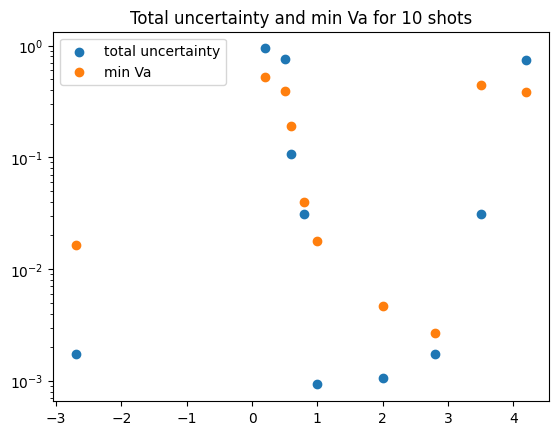

In [12]:
# plot x vs total uncertainty and min Va

plt.figure()
plt.scatter(shots_df['true_x'], shots_df['total_uncertainty'], label='total uncertainty')
plt.scatter(shots_df['true_x'], shots_df['min_Va'], label='min Va')
plt.title(f"Total uncertainty and min Va for {shots} shots")
plt.yscale('log')
plt.legend()
plt.show()

In [6]:
x_index = 5

In [7]:
# Data for specific x values


# Load results
shot_values = []
total_uncertainty_list = []
min_Va_list = []
max_Ve_list = []
true_x_list = []

for filename in os.listdir(results_directory):
    if f"x{x_index}" in filename:
        df = pd.read_csv(results_directory + filename)
        # Get the shot value from the filename "_{shot_value}_shot"
        shot_value = int(re.search(r'_(\d+)_shot', filename).group(1))
        shot_values.append(shot_value)
        
        total_uncertainty = df["H[p(y|x)]"].values[0]
        total_uncertainty_list.append(total_uncertainty)
        
        min_Va = df["min_Va"].values[0]
        min_Va_list.append(min_Va)
        
        max_Ve = df["max_Ve"].values[0]
        max_Ve_list.append(max_Ve)
        
        true_x = df['true_x'].values[0]
        true_x_list.append(true_x)
        
# Create a dataframe from the lists
data = {'shot_values': shot_values,
        'total_uncertainty': total_uncertainty_list,
        'min_Va': min_Va_list,
        'max_Ve': max_Ve_list,
        'true_x': true_x_list}

x_df = pd.DataFrame(data)

x_df = x_df.sort_values(by='shot_values')

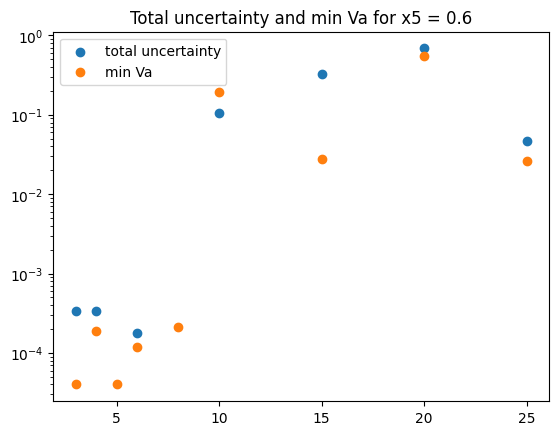

In [8]:
# plot shot values vs total uncertainty and min Va

plt.figure()
plt.scatter(x_df['shot_values'], x_df['total_uncertainty'], label='total uncertainty')
plt.scatter(x_df['shot_values'], x_df['min_Va'], label='min Va')
plt.title(f"Total uncertainty and min Va for x{x_index} = {x_df['true_x'].values[0]}")
plt.yscale("log")
plt.legend()
plt.show()